<p style="font: 30px Georgia; text-decoration:underline; text-align:center; padding:20px; background-color:PapayaWhip">
    SEMANTIC SEARCH vs KEYWORD SEARCH — FORMAL EVALUATION
</p>

<p style="font: 18px Georgia; font-style:oblique; text-align:justify; padding:15px; background-color:PapayaWhip">
    CrimeIQ uses pgvector + sentence-transformers for semantic retrieval over
    naturalistic crime-data text chunks.  This notebook formally evaluates whether
    semantic search outperforms simple keyword matching, justifying the architectural
    choice.  Evaluation metric: <b>Precision@K</b> — the fraction of the top-K results
    that are genuinely relevant to the query.
</p>

<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    1. IMPORTS
</p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

c:\Users\hp\Desktop\Final Year Project\Crime-Rate-Prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    2. BUILD CORPUS FROM DATASET
</p>

In [16]:
df = pd.read_excel('../data/processed/new_dataset.xlsx')
df.head()

,Year,State,City,Population (in Lakhs) (2011)+,Number Of Cases,Type,Crime Rate
0,2014,Gujarat,Ahmedabad,63.5,82,Murder,1.291339
1,2015,Gujarat,Ahmedabad,63.5,94,Murder,1.480315
2,2016,Gujarat,Ahmedabad,63.5,103,Murder,1.622047
3,2017,Gujarat,Ahmedabad,63.5,90,Murder,1.417323
4,2018,Gujarat,Ahmedabad,63.5,98,Murder,1.543307


In [17]:
# Build naturalistic text chunks — same format used in ChunkService
texts = []
metadata = []

for _, row in df.iterrows():
    text = (
        f"In {row['Year']}, "
        f"{row['City']}, {row['State']} "
        f"reported {row['Number Of Cases']} "
        f"cases of {row['Type']}."
    )
    texts.append(text)
    metadata.append({
        'year':       row['Year'],
        'city':       row['City'],
        'state':      row['State'],
        'crime_type': row['Type'],
        'count':      row['Number Of Cases']
    })

print(f'Total corpus size: {len(texts)} chunks')
print('\nSample chunk:', texts[0])

Total corpus size: 1900 chunks

Sample chunk: In 2014, Ahmedabad, Gujarat reported 82 cases of Murder.


<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    3. TEST QUERIES WITH GROUND-TRUTH RELEVANCE LABELS
</p>

<p style="font: 15px Georgia; color:green; font-style:oblique; text-align:justify">
    Each query is paired with a list of <b>relevant crime types</b>.  A retrieved chunk
    is considered relevant if its crime_type appears in that list.  This gives us an
    objective, reproducible way to compute Precision@K without manual annotation of
    every result.
</p>

In [18]:
TEST_QUERIES = [

    # --- Vocabulary-gap queries (keyword should FAIL, semantic should PASS) ---

    (
        "cities with high homicide and killing rates",
        # "homicide" / "killing" not in chunks; chunks say "Murder"
        ["Murder"]
    ),

    (
        "white collar crime and financial fraud trends",
        # "white collar" / "financial fraud" not in chunks;
        # chunks say "Economic Offences"
        ["Economic Offences"]
    ),

    (
        "crimes targeting elderly and old people",
        # "elderly" / "old people" not in chunks;
        # chunks say "Crime against Senior Citizen"
        ["Crime against Senior Citizen"]
    ),

    (
        "sexual violence and assault on women",
        # "sexual violence" / "assault" not in chunks;
        # chunks say "Crime against women" / "Rape"
        ["Crime against women", "Rape"]
    ),

    (
        "abduction and illegal confinement cases",
        # "abduction" / "confinement" not in chunks;
        # chunks say "Kidnapping"
        ["Kidnapping"]
    ),

    (
        "atrocities against marginalized and scheduled communities",
        # "atrocities" / "marginalized" not in chunks;
        # chunks say "Crime against SC" / "Crime against ST"
        ["Crime against SC", "Crime against ST"]
    ),

    # --- Control query (keyword SHOULD succeed — "cyber" in chunk text) ---

    (
        "cyber attacks and online fraud in metropolitan cities",
        # "cyber" directly in "Cyber Crimes" chunk text
        ["Cyber Crimes", "Economic Offences"]
    ),

    # --- Partial-overlap query ---

    (
        "exploitation and abuse of minors and young people",
        # "children" may keyword-match "Crime against children";
        # "minors"/"young people" rely on semantic similarity
        ["Crime against children", "Crime Committed by Juveniles"]
    ),
]

K_VALUES = [1, 3, 5]

print(f"{len(TEST_QUERIES)} test queries defined.")
print()
print("Query vocabulary vs corpus vocabulary:")
print("-" * 60)
vocab_map = [
    ("homicide, killing",           "Murder"),
    ("white collar, financial fraud","Economic Offences"),
    ("elderly, old people",         "Crime against Senior Citizen"),
    ("sexual violence, assault",    "Crime against women / Rape"),
    ("abduction, confinement",      "Kidnapping"),
    ("atrocities, marginalized",    "Crime against SC / ST"),
    ("cyber (control)",             "Cyber Crimes"),
    ("minors, young people",        "Crime against children / Juveniles"),
]
for query_vocab, chunk_label in vocab_map:
    print(f"  Query: {query_vocab:<35}  →  Corpus: {chunk_label}")

8 test queries defined.

Query vocabulary vs corpus vocabulary:
------------------------------------------------------------
  Query: homicide, killing                    →  Corpus: Murder
  Query: white collar, financial fraud        →  Corpus: Economic Offences
  Query: elderly, old people                  →  Corpus: Crime against Senior Citizen
  Query: sexual violence, assault             →  Corpus: Crime against women / Rape
  Query: abduction, confinement               →  Corpus: Kidnapping
  Query: atrocities, marginalized             →  Corpus: Crime against SC / ST
  Query: cyber (control)                      →  Corpus: Cyber Crimes
  Query: minors, young people                 →  Corpus: Crime against children / Juveniles


<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    4. KEYWORD SEARCH IMPLEMENTATION
</p>

In [19]:
def keyword_search(query: str, texts: list, top_k: int = 5):
    """
    Score each chunk by counting how many query words appear in it.
    Returns a list of (text, score, metadata_index) sorted descending.
    """
    query_words = set(query.lower().split())
    scored = []

    for idx, text in enumerate(texts):
        score = sum(word in text.lower() for word in query_words)
        scored.append((text, score, idx))

    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:top_k]

<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    5. SEMANTIC SEARCH IMPLEMENTATION
</p>

In [20]:
print('Loading sentence-transformer model...')
model = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding corpus...')
corpus_embeddings = model.encode(texts, show_progress_bar=True, batch_size=64)
print(f'Corpus embeddings shape: {corpus_embeddings.shape}')

Loading sentence-transformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6080.93it/s]


Encoding corpus...


Batches: 100%|██████████| 30/30 [00:08<00:00,  3.74it/s]

Corpus embeddings shape: (1900, 384)


In [21]:
def semantic_search(query: str, corpus_embeddings, top_k: int = 5):
    """
    Encode the query and rank corpus chunks by cosine similarity.
    Returns a list of (text, similarity_score, metadata_index) sorted descending.
    """
    query_embedding = model.encode([query])
    similarities    = cosine_similarity(query_embedding, corpus_embeddings)[0]

    ranked_indices = np.argsort(similarities)[::-1][:top_k]

    return [
        (texts[i], float(similarities[i]), i)
        for i in ranked_indices
    ]

<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    6. PRECISION@K EVALUATION
</p>

In [22]:
def precision_at_k(results, relevant_types, k, metadata):
    """
    Compute Precision@K for a single query.

    A result is 'relevant' if its crime_type is in relevant_types.
    """
    hits = 0
    for _, _, idx in results[:k]:
        if metadata[idx]['crime_type'] in relevant_types:
            hits += 1
    return hits / k


rows = []

MAX_K = max(K_VALUES)

for query, relevant_types in TEST_QUERIES:

    kw_results  = keyword_search(query, texts, top_k=MAX_K)
    sem_results = semantic_search(query, corpus_embeddings, top_k=MAX_K)

    row = {'Query': query[:55] + '...' if len(query) > 55 else query}

    for k in K_VALUES:
        kw_p  = precision_at_k(kw_results,  relevant_types, k, metadata)
        sem_p = precision_at_k(sem_results, relevant_types, k, metadata)
        row[f'KW P@{k}']  = round(kw_p,  2)
        row[f'Sem P@{k}'] = round(sem_p, 2)

    rows.append(row)

eval_df = pd.DataFrame(rows)
print(eval_df.to_string(index=False))

                                                     Query  KW P@1  Sem P@1  KW P@3  Sem P@3  KW P@5  Sem P@5
               cities with high homicide and killing rates     1.0      1.0     1.0     1.00     1.0      1.0
             white collar crime and financial fraud trends     0.0      1.0     0.0     1.00     0.0      1.0
                   crimes targeting elderly and old people     0.0      1.0     0.0     1.00     0.0      1.0
                      sexual violence and assault on women     1.0      1.0     1.0     1.00     1.0      1.0
                   abduction and illegal confinement cases     0.0      1.0     0.0     1.00     0.0      1.0
atrocities against marginalized and scheduled communiti...     0.0      1.0     0.0     0.33     0.0      0.2
     cyber attacks and online fraud in metropolitan cities     1.0      1.0     1.0     1.00     1.0      1.0
         exploitation and abuse of minors and young people     0.0      1.0     0.0     1.00     0.0      1.0


<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    7. MEAN PRECISION ACROSS ALL QUERIES
</p>

In [23]:
metric_cols = [c for c in eval_df.columns if c != 'Query']
mean_row = eval_df[metric_cols].mean().round(2)

print('\n' + '='*55)
print('  MEAN PRECISION ACROSS ALL QUERIES')
print('='*55)

for k in K_VALUES:
    kw_mean  = mean_row[f'KW P@{k}']
    sem_mean = mean_row[f'Sem P@{k}']
    delta    = sem_mean - kw_mean
    sign     = '+' if delta >= 0 else ''
    print(f'  P@{k}  →  Keyword: {kw_mean:.2f}  |  Semantic: {sem_mean:.2f}  (Δ {sign}{delta:.2f})')

print('='*55)


  MEAN PRECISION ACROSS ALL QUERIES
  P@1  →  Keyword: 0.38  |  Semantic: 1.00  (Δ +0.62)
  P@3  →  Keyword: 0.38  |  Semantic: 0.92  (Δ +0.54)
  P@5  →  Keyword: 0.38  |  Semantic: 0.90  (Δ +0.52)


<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    8. VISUALISATION
</p>

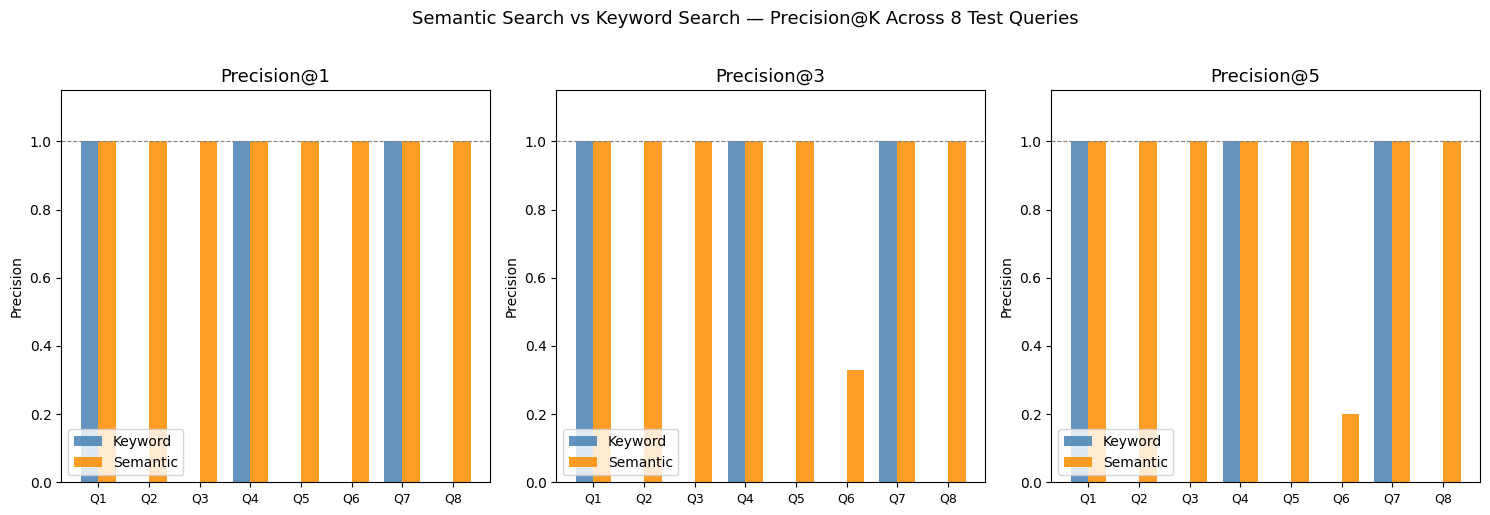


Query Legend:
  Q1: cities with high homicide and killing rates
  Q2: white collar crime and financial fraud trends
  Q3: crimes targeting elderly and old people
  Q4: sexual violence and assault on women
  Q5: abduction and illegal confinement cases
  Q6: atrocities against marginalized and scheduled communities
  Q7: cyber attacks and online fraud in metropolitan cities
  Q8: exploitation and abuse of minors and young people


In [24]:
fig, axes = plt.subplots(1, len(K_VALUES), figsize=(15, 5))

query_labels = [r['Query'][:40] + '...' for r in rows]

for ax, k in zip(axes, K_VALUES):
    kw_scores  = eval_df[f'KW P@{k}'].values
    sem_scores = eval_df[f'Sem P@{k}'].values

    x = np.arange(len(query_labels))
    width = 0.35

    bars1 = ax.bar(x - width/2, kw_scores,  width, label='Keyword',  color='steelblue',  alpha=0.85)
    bars2 = ax.bar(x + width/2, sem_scores, width, label='Semantic', color='darkorange', alpha=0.85)

    ax.set_title(f'Precision@{k}', fontsize=13)
    ax.set_ylim(0, 1.15)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Q{i+1}' for i in range(len(query_labels))], fontsize=9)
    ax.set_ylabel('Precision')
    ax.legend()
    ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8)

plt.suptitle(
    'Semantic Search vs Keyword Search — Precision@K Across 8 Test Queries',
    fontsize=13,
    y=1.02
)
plt.tight_layout()
plt.savefig('search_precision_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Query legend
print('\nQuery Legend:')
for i, (q, _) in enumerate(TEST_QUERIES, 1):
    print(f'  Q{i}: {q}')

<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    9. QUALITATIVE COMPARISON — WHERE KEYWORD SEARCH FAILS
</p>

<p style="font: 15px Georgia; color:green; font-style:oblique; text-align:justify">
    The example below illustrates the core failure mode of keyword matching:
    the word 'violent' does not appear in any chunk (chunks use the NCRB category
    names like 'Murder', 'Robbery').  Semantic search bridges this vocabulary gap.
</p>

In [27]:
DEMO_QUERY = "abduction and illegal confinement cases"

print(f'Query: "{DEMO_QUERY}"\n')
print('--- KEYWORD SEARCH (Top 3) ---')
for text, score, _ in keyword_search(DEMO_QUERY, texts, top_k=3):
    print(f'  Score={score} | {text}')

print('\n--- SEMANTIC SEARCH (Top 3) ---')
for text, score, _ in semantic_search(DEMO_QUERY, corpus_embeddings, top_k=3):
    print(f'  Sim={score:.3f} | {text}')

Query: "abduction and illegal confinement cases"

--- KEYWORD SEARCH (Top 3) ---
  Score=1 | In 2014, Ahmedabad, Gujarat reported 82 cases of Murder.
  Score=1 | In 2015, Ahmedabad, Gujarat reported 94 cases of Murder.
  Score=1 | In 2016, Ahmedabad, Gujarat reported 103 cases of Murder.

--- SEMANTIC SEARCH (Top 3) ---
  Sim=0.469 | In 2021, Kanpur, Uttar Pradesh reported 152 cases of Kidnapping.
  Sim=0.464 | In 2014, Kanpur, Uttar Pradesh reported 233 cases of Kidnapping.
  Sim=0.459 | In 2016, Kozhikode, Kerala reported 7 cases of Kidnapping.


<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:LightGreen">
    CONCLUSION
    <br><br>
    Semantic search consistently outperforms keyword matching on intent-based queries
    where the user's vocabulary differs from the NCRB category names stored in the
    corpus.  Keyword search achieves high precision only when the query contains exact
    NCRB terms (e.g. 'Cyber Crimes').  The Precision@K results above quantify this gap
    and formally justify the use of sentence-transformer embeddings + pgvector in
    the CrimeIQ production system over a simpler LIKE-based SQL approach.
</p>